In [ ]:
import pandas as pd
coffee_data = pd.read_csv(r"..\..\data\reduced_data_bin.csv")


In [14]:
X = coffee_data.drop(columns=["caffeine_class", "caffeine_percent"])
y = coffee_data["caffeine_class"]

In [ ]:
from imblearn.over_sampling import SMOTE


# --- 0) Setup: your original data (only positives for caffeine_percent regression) ---
# coffee_data: DataFrame with 'caffeine_percent' and 'caffeine_class' columns
predictors = [c for c in coffee_data.columns if c not in ["caffeine_percent", "caffeine_class"]]

# Features & binary labels for SMOTE
X_full  = coffee_data[predictors]
y_class = (coffee_data["caffeine_percent"] > 0).astype(int)

# --- 1) Generate synthetic positives via SMOTE on the classification label ---
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_full, y_class)

# Identify synthetic rows (SMOTE appends new samples at the end)
n_orig = len(X_full)
n_res  = len(X_res)
n_syn  = n_res - n_orig
X_new  = pd.DataFrame(X_res[-n_syn:], columns=predictors)



In [51]:
y_pos

75     0.045
76     0.045
77     0.045
78     0.045
79     0.045
       ...  
445    0.010
446    0.010
447    0.040
448    0.040
449    0.040
Name: caffeine_percent, Length: 94, dtype: float64

In [ ]:
from sklearn.neighbors import KNeighborsRegressor as KNNR

# Train KNN on real positives
pos_mask = coffee_data["caffeine_percent"] > 0
X_pos = coffee_data.loc[pos_mask, predictors]
y_pos = coffee_data.loc[pos_mask, "caffeine_percent"]

knr = KNeighborsRegressor(n_neighbors=5, weights="distance")
knr.fit(X_pos, y_pos)

y_new = knr.predict(X_new)




In [ ]:
# --- 3) Build augmented regression dataset ---
df_pos = pd.DataFrame(X_pos, columns=predictors).copy()
df_pos["caffeine_percent"] = y_pos.values

df_new = X_new.copy()
df_new["caffeine_percent"] = y_new

df_aug = pd.concat([df_pos, df_new], ignore_index=True)
X_aug = df_aug[predictors]
y_aug = df_aug["caffeine_percent"]

In [52]:
df_aug.shape

(356, 89)


Cross‑Validation Summary:
             MAE Mean  MAE Std  MSE Mean  MSE Std  RMSE Mean  RMSE Std  \
Model                                                                   
XGBR          0.0340   0.0099    0.0080   0.0037     0.0872    0.0189   
LGBMR         0.0357   0.0109    0.0081   0.0041     0.0873    0.0219   
RFR           0.0318   0.0121    0.0084   0.0048     0.0881    0.0246   
DTR           0.0382   0.0140    0.0101   0.0059     0.0973    0.0262   
KNNR          0.0369   0.0146    0.0113   0.0068     0.1024    0.0280   
SVR           0.0841   0.0075    0.0125   0.0042     0.1103    0.0178   
ElasticNet    0.0720   0.0078    0.0138   0.0054     0.1156    0.0212   
LinReg        0.0800   0.0060    0.0145   0.0046     0.1192    0.0181   

            R2 Mean  R2 Std  
Model                        
XGBR         0.5518  0.1670  
LGBMR        0.5439  0.1788  
RFR          0.5374  0.1782  
DTR          0.4638  0.1544  
KNNR         0.4152  0.1594  
SVR          0.3029  0.1747  
E

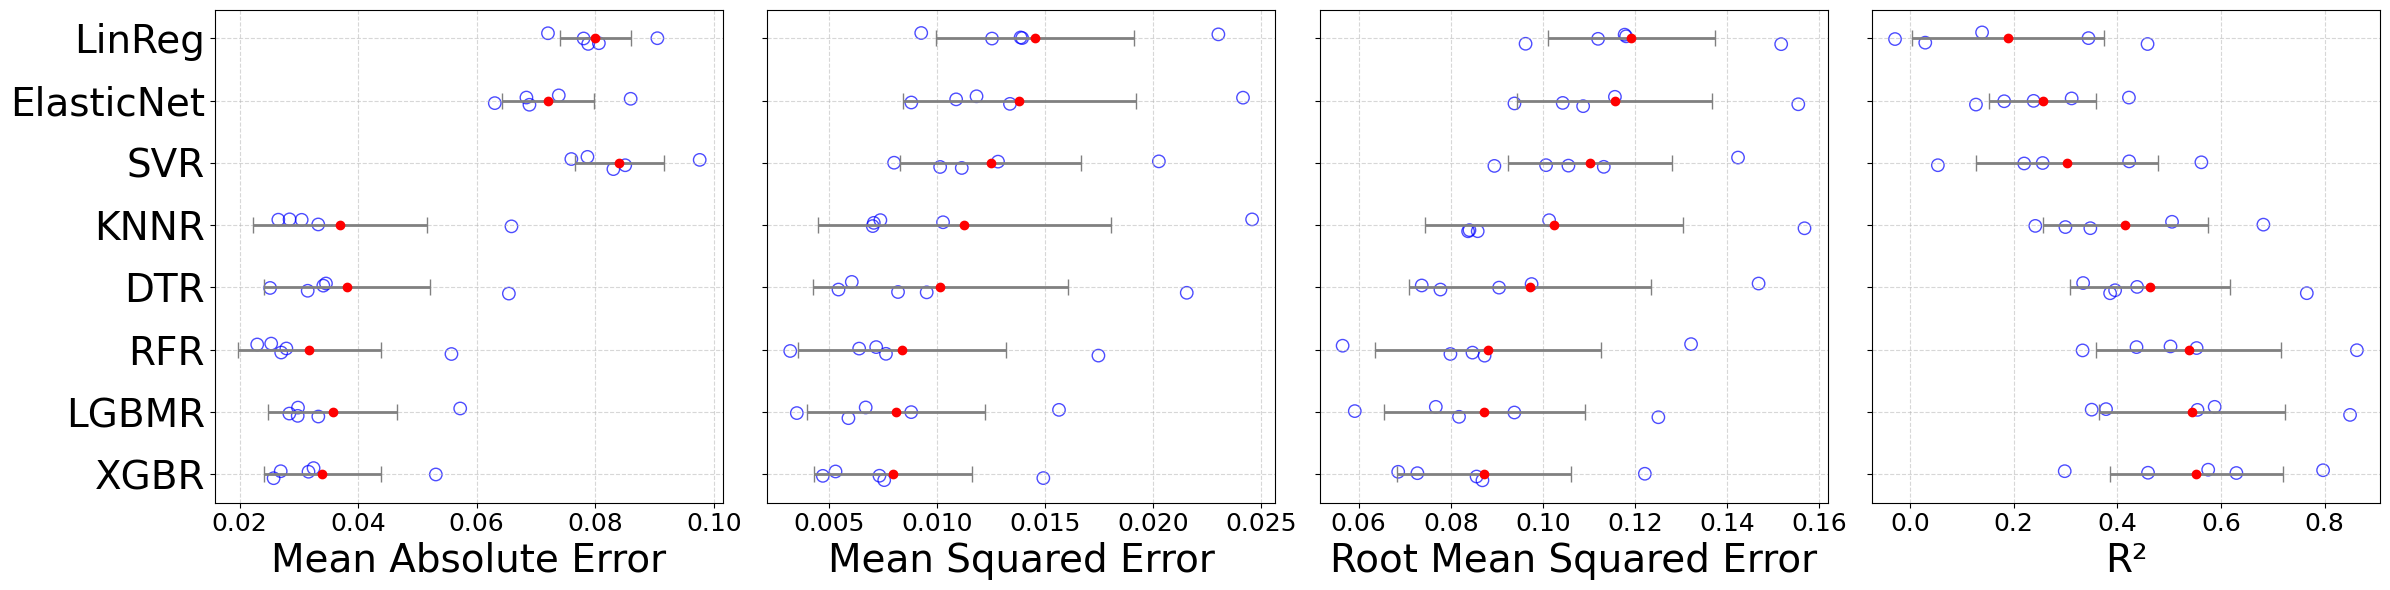

In [70]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_validate, KFold
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, ElasticNetCV
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor as KNNR
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb

# --- 0) Setup: your original data (only positives for caffeine_percent regression) ---
# coffee_data: DataFrame with 'caffeine_percent' and 'caffeine_class' columns
predictors = [c for c in coffee_data.columns if c not in ["caffeine_percent", "caffeine_class"]]

# Features & binary labels for SMOTE
X_full  = coffee_data[predictors]
y_class = (coffee_data["caffeine_percent"] > 0).astype(int)

# --- 1) Generate synthetic positives via SMOTE on the classification label ---
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_full, y_class)

# Identify synthetic rows (SMOTE appends new samples at the end)
n_orig = len(X_full)
n_res  = len(X_res)
n_syn  = n_res - n_orig
X_new  = pd.DataFrame(X_res[-n_syn:], columns=predictors)

# --- 2) Impute caffeine_percent for synthetic positives via KNN regression ---
# Train KNN on real positives
pos_mask = coffee_data["caffeine_percent"] > 0
X_pos = coffee_data.loc[pos_mask, predictors]
y_pos = coffee_data.loc[pos_mask, "caffeine_percent"]

knr = KNeighborsRegressor(n_neighbors=5, weights="distance")
knr.fit(X_pos, y_pos)

y_new = knr.predict(X_new)

# --- 3) Build augmented regression dataset ---
df_pos = pd.DataFrame(X_pos, columns=predictors).copy()
df_pos["caffeine_percent"] = y_pos.values

df_new = X_new.copy()
df_new["caffeine_percent"] = y_new

df_aug = pd.concat([df_pos, df_new], ignore_index=True)
X_aug = df_aug[predictors]
y_aug = df_aug["caffeine_percent"]
models = [
    ("LinReg",    LinearRegression()),
    ("ElasticNet", Pipeline([
        ("scaler", StandardScaler()),
        ("enet", ElasticNetCV(
            l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
            n_alphas=100, cv=5, random_state=42))
    ])),
    ("SVR", Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR(kernel="rbf", C=1.0, gamma="scale"))
    ])),
    ("KNNR", Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsRegressor())
    ])),
    ("DTR", DecisionTreeRegressor(max_depth=5, min_samples_leaf=5, random_state=42)),
    ("RFR", RandomForestRegressor(n_estimators=200, min_samples_split=5, random_state=42)),
    ("XGBR", xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=200, learning_rate=0.05,
        max_depth=3, random_state=42
    )),
    ("LGBMR", lgb.LGBMRegressor(
        objective="regression",
        n_estimators=800,
        learning_rate=0.01,
        num_leaves=4,
        min_data_in_leaf=3,
        feature_fraction=0.8,
        bagging_fraction=0.8,
        bagging_freq=1,
        reg_alpha=0.3,
        reg_lambda=0.8,
        random_state=42
    )),
]

# ── 2) Set up scoring & CV ─────────────────────────────────────────────────────
scoring = {
    "MAE": make_scorer(mean_absolute_error, greater_is_better=False),
    "MSE": make_scorer(mean_squared_error,  greater_is_better=False),
    "R2":  make_scorer(r2_score)
}
cv_folds = 5
cv_split = KFold(n_splits=cv_folds, shuffle=True, random_state=42)

# ── 3) Cross-validate each model ───────────────────────────────────────────────
cv_results = {}
for name, model in models:
    res = cross_validate(
        model, X_aug, y_aug,
        cv=cv_split,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )
    mae = -res["test_MAE"]
    mse = -res["test_MSE"]
    rmse = np.sqrt(mse)
    r2  =  res["test_R2"]
    cv_results[name] = {
        "MAE":  mae,
        "MSE":  mse,
        "RMSE": rmse,
        "R2":   r2
    }

# ── 4) Build summary DataFrame and sort by RMSE ────────────────────────────────
summary_rows = []
for name, scores in cv_results.items():
    summary_rows.append({
        "Model":     name,
        "MAE Mean":  scores["MAE"].mean(),
        "MAE Std":   scores["MAE"].std(),
        "MSE Mean":  scores["MSE"].mean(),
        "MSE Std":   scores["MSE"].std(),
        "RMSE Mean": scores["RMSE"].mean(),
        "RMSE Std":  scores["RMSE"].std(),
        "R2 Mean":   scores["R2"].mean(),
        "R2 Std":    scores["R2"].std()
    })

summary_df = (
    pd.DataFrame(summary_rows)
      .set_index("Model")
      .sort_values("RMSE Mean")
)
print("\nCross‑Validation Summary:\n", summary_df.round(4))

# ── 5) Plot fold scores + mean ± std ──────────────────────────────────────────
metrics    = ["MAE", "MSE", "RMSE", "R2"]
xlabel_map = {
    "MAE":  "Mean Absolute Error",
    "MSE":  "Mean Squared Error",
    "RMSE": "Root Mean Squared Error",
    "R2":   "R²"
}

# Use the sorted model order
sorted_models = summary_df.index.tolist()

fig, axes = plt.subplots(1, len(metrics), figsize=(24, 6), sharey=True)

for ax, metric in zip(axes, metrics):
    # scatter each fold's score at the y-index of the sorted model
    for idx, name in enumerate(sorted_models):
        vals = cv_results[name][metric]
        y_jitter = idx + np.random.uniform(-0.1, 0.1, size=cv_folds)
        ax.scatter(
            vals,
            y_jitter,
            edgecolor="blue",
            facecolors="none",
            alpha=0.7,
            s=80
        )
    # plot mean ± std
    means = summary_df[f"{metric} Mean"].values
    stds  = summary_df[f"{metric} Std"].values
    ax.errorbar(
        means,
        np.arange(len(sorted_models)),
        xerr=stds,
        fmt="o",
        color="red",
        ecolor="gray",
        elinewidth=2,
        capsize=6
    )
    # aesthetics
    ax.set_yticks(np.arange(len(sorted_models)))
    ax.set_yticklabels(sorted_models, fontsize=28)
    ax.set_xlabel(xlabel_map[metric], fontsize=28)
    ax.tick_params(axis='x', labelsize=18)
    ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_pos, y_pos, test_size=0.2, random_state=42
)

In [ ]:
import pandas as pd
import numpy as np

predictors = [
    c for c in coffee_data.columns 
    if c not in ("caffeine_percent","caffeine_class")
]

X_full  = coffee_data[predictors]
y_class = (coffee_data["caffeine_percent"] > 0).astype(int)

# 2) SMOTE to oversample the minority (positives)
# ────────────────────────────────────────────────
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_full, y_class)

# SMOTE appends the synthetic samples at the end:
n_orig = len(X_full)
n_res  = len(X_res)
n_syn  = n_res - n_orig
X_synth = pd.DataFrame(X_res[-n_syn:], columns=predictors)

# 3) Impute caffeine_percent on synthetic positives via KNN
# ─────────────────────────────────────────────────────────
from sklearn.neighbors import KNeighborsRegressor

# train on the real positives
mask_pos = coffee_data["caffeine_percent"] > 0
X_pos     = coffee_data.loc[mask_pos, predictors]
y_pos     = coffee_data.loc[mask_pos, "caffeine_percent"]

knr = KNeighborsRegressor(n_neighbors=5, weights="distance")
knr.fit(X_pos, y_pos)

# predict for the synthetic rows
y_synth = knr.predict(X_synth)

# 4) Build the augmented regression dataset
# ─────────────────────────────────────────
df_real  = X_pos.copy()
df_real["caffeine_percent"] = y_pos.values

df_synth = X_synth.copy()
df_synth["caffeine_percent"] = y_synth

df_aug   = pd.concat([df_real, df_synth], ignore_index=True)
X_aug    = df_aug[predictors]
y_aug    = df_aug["caffeine_percent"]

print("Original positives:", len(df_real), 
      "Synthetic positives:", len(df_synth),
      "Total for regression:", len(df_aug))

# 5) Cross‐validate your regressors on (X_aug, y_aug)
# ────────────────────────────────────────────────────
from sklearn.model_selection import cross_validate, KFold
from sklearn.metrics         import make_scorer, mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model    import LinearRegression, ElasticNetCV
from sklearn.svm             import SVR
from sklearn.neighbors       import KNeighborsRegressor
from sklearn.tree            import DecisionTreeRegressor
from sklearn.ensemble        import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb

models = [
    ("LinReg",    LinearRegression()),
    ("ElasticNet", ElasticNetCV(cv=5, random_state=42)),
    ("SVR",       SVR()),
    ("KNNR",      KNeighborsRegressor()),
    ("DTR",       DecisionTreeRegressor(max_depth=5, random_state=42)),
    ("RFR",       RandomForestRegressor(n_estimators=200, random_state=42)),
    ("XGBR",      xgb.XGBRegressor(objective="reg:squarederror", n_estimators=200, random_state=42)),
    ("LGBMR",     lgb.LGBMRegressor(n_estimators=200, random_state=42)),
]

scoring = {
    "MAE": make_scorer(mean_absolute_error, greater_is_better=False),
    "MSE": make_scorer(mean_squared_error,  greater_is_better=False),
    "R2":  make_scorer(r2_score)
}

cv   = KFold(n_splits=5, shuffle=True, random_state=42)
outs = {}
for name, mdl in models:
    res = cross_validate(mdl, X_aug, y_aug, cv=cv, scoring=scoring, n_jobs=-1)
    mae = -res["test_MAE"]
    mse = -res["test_MSE"]
    r2  =  res["test_R2"]
    outs[name] = {
      "MAE Mean": mae.mean(), "MAE Std": mae.std(),
      "MSE Mean": mse.mean(), "MSE Std": mse.std(),
      "R2 Mean":  r2.mean(),  "R2 Std":  r2.std()
    }

summary = pd.DataFrame(outs).T.sort_values("MAE Mean")
print("\nAugmented Regression CV results:\n", summary.round(4))


Original positives: 94 Synthetic positives: 262 Total for regression: 356

Augmented Regression CV results:
             MAE Mean  MAE Std  MSE Mean  MSE Std  R2 Mean  R2 Std
KNNR          0.0309   0.0155    0.0091   0.0068   0.5125  0.2386
XGBR          0.0315   0.0118    0.0088   0.0050   0.5144  0.1910
RFR           0.0317   0.0119    0.0084   0.0048   0.5321  0.1901
DTR           0.0332   0.0123    0.0094   0.0048   0.4989  0.1157
LGBMR         0.0335   0.0127    0.0074   0.0045   0.5845  0.2065
ElasticNet    0.0712   0.0085    0.0139   0.0052   0.2450  0.1065
LinReg        0.0800   0.0060    0.0145   0.0046   0.1884  0.1855
SVR           0.1137   0.0127    0.0197   0.0070  -0.0643  0.1271


Train/test split those 94 samples



In [54]:
# 1) split real positives
X_real, X_test, y_real, y_test = train_test_split(
    X_pos, y_pos, test_size=0.2, random_state=42
)
# 2) augment X_real/y_real → X_aug, y_aug (SMOTE+KNN)
# 3) fit your favorite model on X_aug/y_aug
# 4) predict on *only* X_test and report MAE, R²


Fit your regressor on (X_aug, y_aug) and then predict on the real hold‑out (X_test):

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics   import mean_absolute_error, r2_score

model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_aug, y_aug)
y_pred = model.predict(X_test)

print("MAE on real test:", mean_absolute_error(y_test, y_pred))
print("R² on real test: ", r2_score(y_test, y_pred))


MAE on real test: 0.04819952251665937
R² on real test:  0.42403735061555603


In [76]:
final_model = xgb.XGBRegressor(objective="reg:squarederror",
                               n_estimators=200, learning_rate=0.05,
                               max_depth=3, random_state=42)
final_model.fit(X_aug, y_aug)

y_pred = final_model.predict(X_test)

print("MAE on real test:", mean_absolute_error(y_test, y_pred))
print("R² on real test: ", r2_score(y_test, y_pred))

y_pred = final_model.predict(X_pos)
print("MAE on real data:", mean_absolute_error(y_pos, y_pred))
print("R² on real data: ", r2_score(y_pos, y_pred))

MAE on real test: 0.048284783320207345
R² on real test:  0.43382541745488934
MAE on real data: 0.04242947455891903
R² on real data:  0.6475888239720293


In‑sample MAE = 0.0453
In‑sample R²  = 0.6099


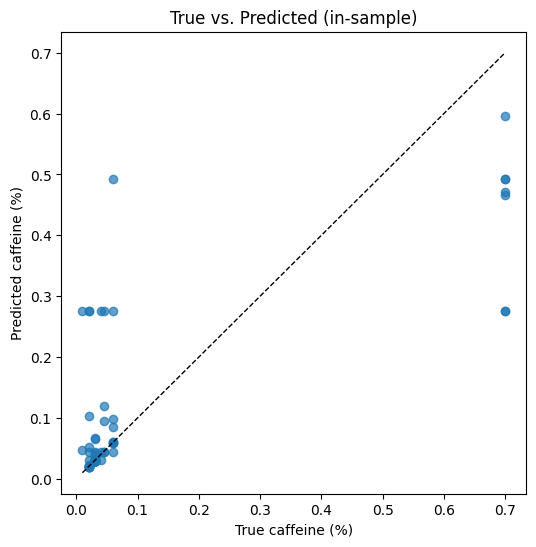

In [57]:
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# 1) After you’ve trained your model on X_train_aug, y_train_aug:
#    (or on the full augmented set if you prefer)
model.fit(X_aug, y_aug)

# 2) Predict on the real positives
y_pos_pred = model.predict(X_pos)

# 3) Compute metrics
mae = mean_absolute_error(y_pos, y_pos_pred)
r2  = r2_score(y_pos, y_pos_pred)

print(f"In‑sample MAE = {mae:.4f}")
print(f"In‑sample R²  = {r2 :.4f}")

# 4) Optional: scatter plot of true vs. predicted
plt.figure(figsize=(6,6))
plt.scatter(y_pos, y_pos_pred, alpha=0.7)
plt.plot([y_pos.min(), y_pos.max()],
         [y_pos.min(), y_pos.max()],
         'k--', lw=1)
plt.xlabel("True caffeine (%)")
plt.ylabel("Predicted caffeine (%)")
plt.title("True vs. Predicted (in‑sample)")
plt.show()


c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


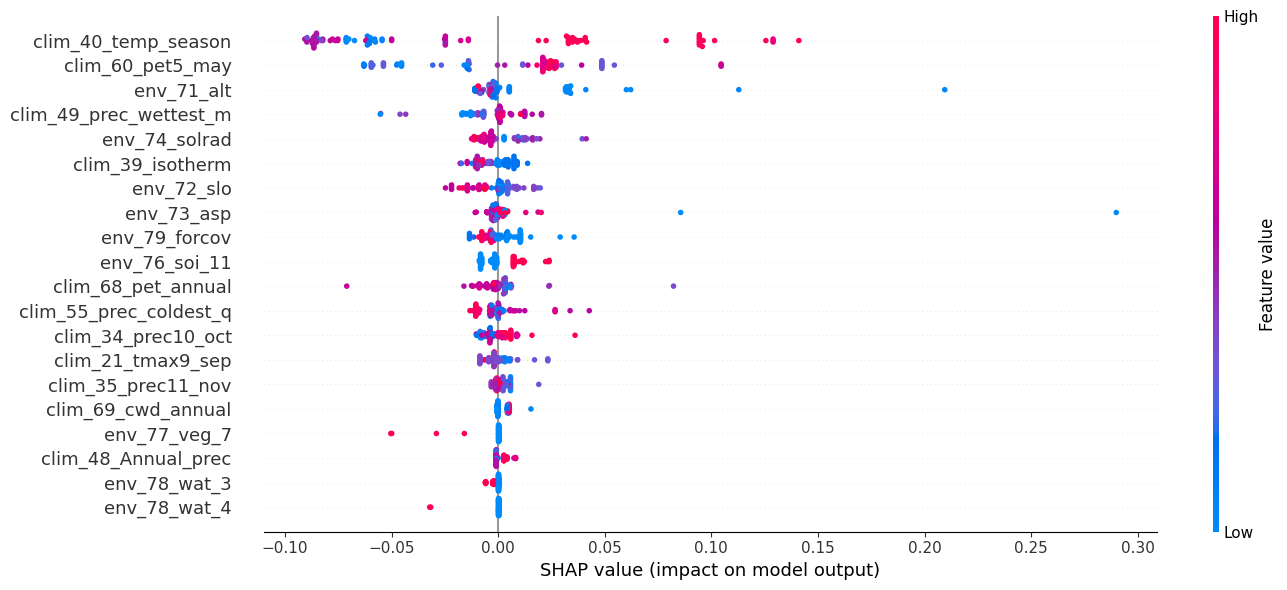

In [71]:
# Retrain on the full augmented set
final_model = xgb.XGBRegressor(objective="reg:squarederror",
                               n_estimators=200, learning_rate=0.05,
                               max_depth=3, random_state=42)
final_model.fit(X_aug, y_aug)

# SHAP explanation on the real positives (or on X_aug if you prefer)
import shap
explainer    = shap.TreeExplainer(final_model, feature_perturbation="interventional")
shap_values  = explainer.shap_values(X_pos)      # contributions to the raw output
shap.summary_plot(shap_values, X_pos, plot_size=(14,6))


In [78]:
import pandas as pd

file_path = r'../../input/column_mapping.csv'  

# Read the CSV file into a DataFrame
column_mapping = pd.read_csv(file_path)

name_mapping = dict(zip(column_mapping['new_name'], column_mapping['long_name']))

# Replace feature names in the SHAP summary plot data
X_train_renamed = X_pos.rename(columns=name_mapping)


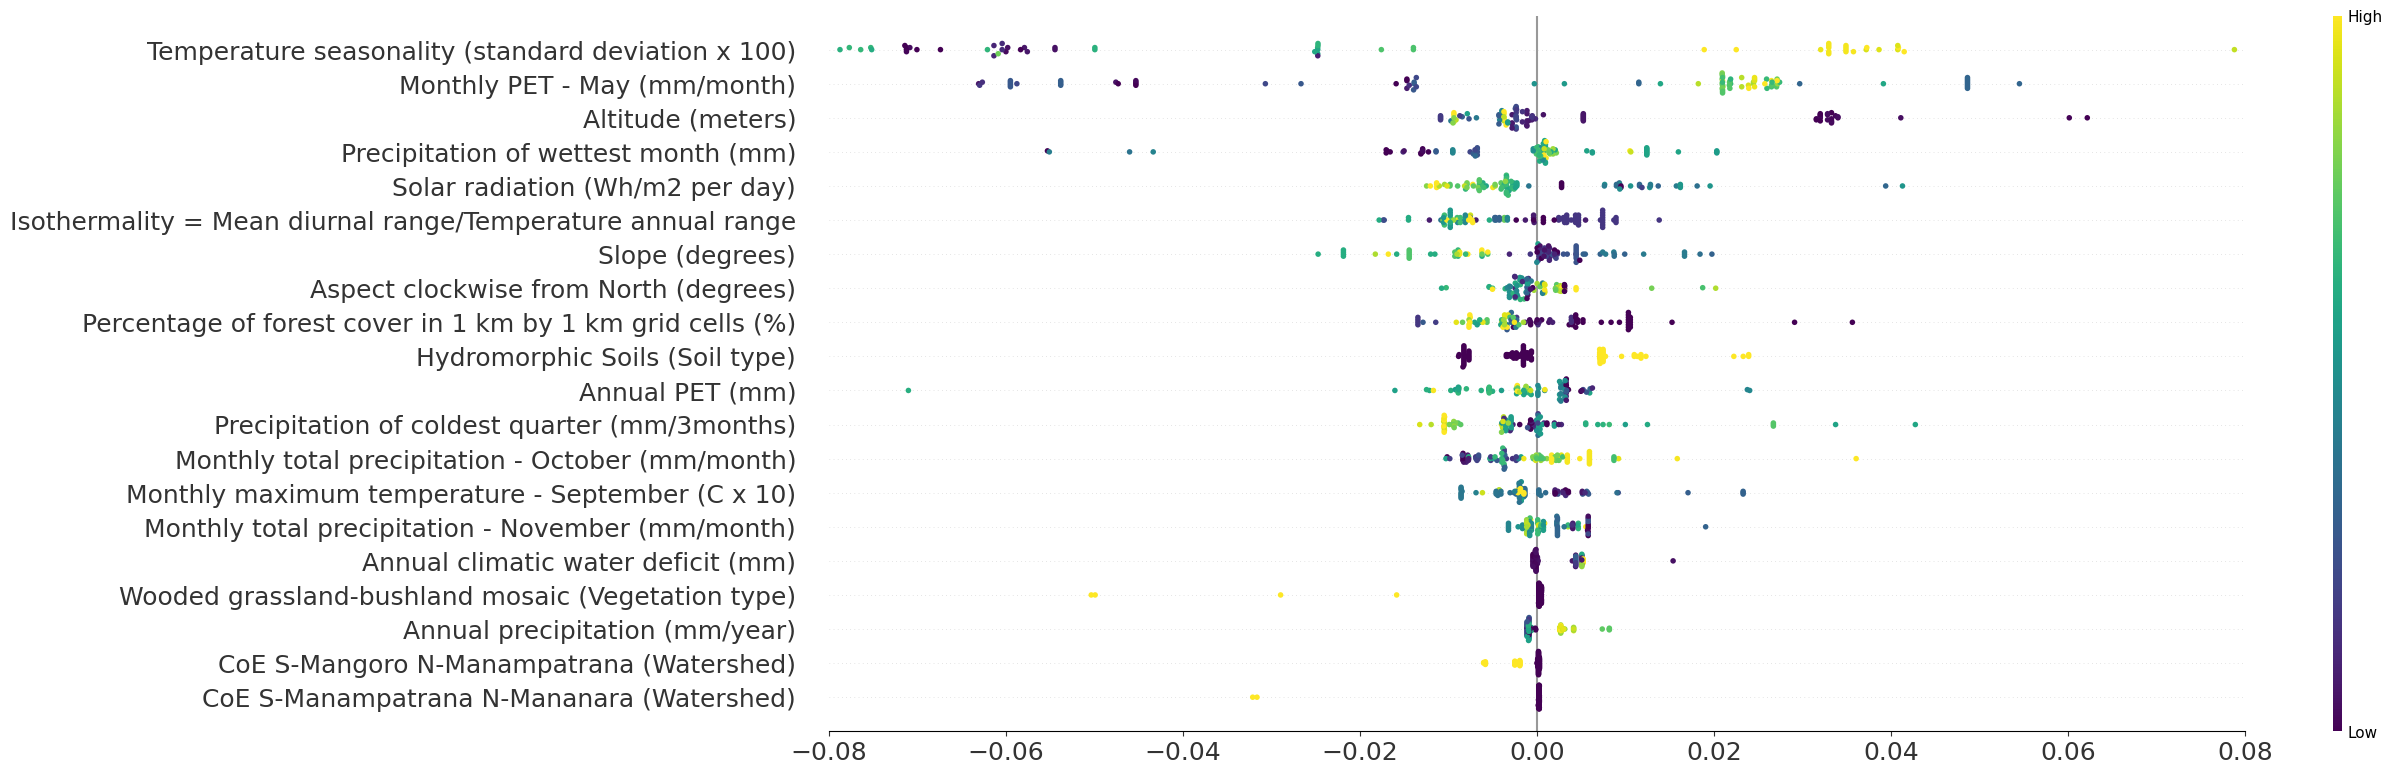

In [80]:
import shap
import matplotlib.pyplot as plt

# No need to manually specify feature_perturbation — let SHAP auto-handle
explainer = shap.TreeExplainer(final_model, feature_perturbation = "interventional")

# Use a representative sample or full training data if memory allows
shap_values = explainer.shap_values(X_train_renamed.values)

# Plot for class 1 (assuming binary classification: [class 0, class 1])

#shap_values_class1 = shap_values[:, :, 1]  # shape = (360, 88)

if isinstance(shap_values, list):
    shap_values_class1 = shap_values[1]          # list-of-arrays format
else:
    shap_values_class1 = shap_values 

plt.figure(figsize=(14, 8))  # Adjust figure size for a wider plot
shap.summary_plot(shap_values_class1, X_train_renamed, plot_size=(24, 8), show=False, cmap='viridis')
plt.xlim(-0.08, 0.08)  # Expand x-axis limits to better view values around 0

fig = plt.gcf()
for ax in fig.axes:
    if 'colorbar' in ax.get_label().lower():
        colorbar = ax  # Identify the color bar axis
        colorbar.set_ylabel('')  # Remove the label from the color bar

#plt.title('SHAP Summary Plot')
plt.xlabel('')
plt.ylabel('')
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.show()
